## analysing the changes in zonal wind stress, STC and tropical pacific temperature anomalies post net zero using ACCESS net zero runs

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd

In [4]:
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [5]:
import cmocean
from scipy import stats

In [6]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [7]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [8]:
from matplotlib.colors import BoundaryNorm as BM
# from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [9]:
def plot_background(ax, draw_labels=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        if draw_labels:
            plot_background(ax, draw_labels)
        else:
            plot_background(ax)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            wind_separation = 5
            q = axlist[i].quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd[i][::wind_separation, ::wind_separation], v_wnd[i][::wind_separation, ::wind_separation], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
            qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])



def plot_single_map(x, y, z, title, label, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    ax = plt.axes(projection=proj)
    if draw_labels:
        plot_background(ax, draw_labels)
    else:
        plot_background(ax)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = 5
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if pval != []:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.1, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])

In [10]:
def plot_maps_no_proj(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_colorbar=True, auto_aspect=False, draw_clabel=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, sharex=True, sharey=True)
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, levels=levels, extend='both')
        if draw_winds:
            wind_separation = 5
            q = axlist[i].quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd[i][::wind_separation, ::wind_separation], v_wnd[i][::wind_separation, ::wind_separation], scale=wind_scale, color='k', pivot='middle')
    
            qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
            qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
        if draw_contour:
            cs = axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, alpha=0.5)
            if draw_clabel:
                axlist[i].clabel(cs, inline=True, fontsize=8)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...')
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...')
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])
    return fig, axlist

In [11]:
from functions import preproc_funcs as funcs

In [12]:
from functions import xr_lowess

In [13]:
import xesmf as xe

In [14]:
def compute_plotting_da(input_da, type='zonal', alternate=False):
    """
    example for trans - thetao_zonal_trans_anom.sel(time = slice('2030', '2060')).mean('time').thetao
    example for stable - thetao_zonal_stable_anom2030.thetao
    """
    if type == 'zonal':
        # ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
        # input_da = input_da.expand_dims(dim = dict(i = 360))
        # input_da['j'] = np.linspace(-90, 90, len(input_da.j))
        # input_da['i'] = np.linspace(0, 360, len(input_da.i))
        # input_da = input_da.rename(dict(i='lon', j='lat'))
        # regridder = xe.Regridder(input_da, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
        # plotting_da = regridder(input_da).mean(('lon'))
        return input_da
    elif type == 'merid':
        if alternate:
            ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
        else:
            ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -5, 5, 1.5)
        # input_da = input_da.expand_dims(dim = dict(j = 40))
        input_da['j'] = input_da['latitude']
        input_da['i'] = input_da['longitude']
        input_da = input_da.rename(dict(i='lon', j='lat'))
        regridder = xe.Regridder(input_da, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
        plotting_da = regridder(input_da).mean(('lat'))
    return plotting_da

In [15]:
# plot_cuboid_contours(zz.to_numpy(), zz.lon.to_numpy(), zz.lat.to_numpy(), plotting_da.thetao.to_numpy(), plotting_da.lat.to_numpy(), plotting_da.lev.to_numpy(), plotting_da_test.thetao.to_numpy(), plotting_da_test.lon.to_numpy(), plotting_da_test.lev.to_numpy())

In [16]:
from mpl_toolkits.mplot3d import Axes3D
import itertools
from matplotlib.collections import LineCollection, PolyCollection
from cartopy.mpl.patch import geos_to_path

In [17]:
# def add_basemap(ax, proj=ccrs.PlateCarree(central_longitude=180), type='land'):
#     if type == 'land':
#         feature = cfeature.NaturalEarthFeature('physical', 'land', '110m')
#         concat = lambda iterable: list(itertools.chain.from_iterable(iterable))
#         geoms = feature.geometries()
#         geoms = [proj.project_geometry(geom, feature.crs) for geom in geoms]
#         paths = concat(geos_to_path(geom) for geom in geoms)
#         polys = concat(path.to_polygons() for path in paths)
#         pc = PolyCollection(polys, edgecolor='none', facecolor='k', closed=False)
#         ax.add_collection3d(pc, zs=0, zdir='z')
#     elif type == 'coastline':
#         feature = cfeature.NaturalEarthFeature('physical', 'coastine', '110m')
#         geoms = feature.geometries()
#         geoms = [proj.project_geometry(geom, feature.crs) for geom in geoms]
#         paths = list(itertools.chain.from_iterable(geos_to_path(geom) for geom in geoms))
#         segments = []
#         for path in paths:
#             vertices = [vertex for vertex, _ in path.iter_segments()]
#             vertices = np.asarray(vertices)
#             segments.append(vertices)
        
#         lc = LineCollection(segments, color='black')
#         ax.add_collection3d(lc, zs=0, zdir='z')

import shapely.geometry as sgeom

def add_basemap(ax, proj=ccrs.PlateCarree(central_longitude=180), type='land',
                lon_min=-180, lon_max=180, lat_min=-90, lat_max=90):
    # Create clipping box polygon in lon/lat coordinates
    clipping_box = sgeom.box(lon_min, lat_min, lon_max, lat_max)  # minx, miny, maxx, maxy
    
    concat = lambda iterable: list(itertools.chain.from_iterable(iterable))

    if type == 'land':
        feature = cfeature.NaturalEarthFeature('physical', 'land', '110m')
        geoms = feature.geometries()
        
        clipped_geoms = []
        for geom in geoms:
            # Project geom to target CRS
            proj_geom = proj.project_geometry(geom, feature.crs)
            # Clip geometry with box in lon/lat
            clipped = proj_geom.intersection(clipping_box)
            if not clipped.is_empty:
                clipped_geoms.append(clipped)
        
        paths = concat(geos_to_path(geom) for geom in clipped_geoms)
        polys = concat(path.to_polygons() for path in paths)
        pc = PolyCollection(polys, edgecolor='none', facecolor='k', closed=False)
        ax.add_collection3d(pc, zs=0, zdir='z')

    elif type == 'coastline':
        feature = cfeature.NaturalEarthFeature('physical', 'coastline', '110m')
        geoms = feature.geometries()
        clipped_geoms = []
        for geom in geoms:
            proj_geom = proj.project_geometry(geom, feature.crs)
            clipped = proj_geom.intersection(clipping_box)
            if not clipped.is_empty:
                clipped_geoms.append(clipped)
        
        paths = concat(geos_to_path(geom) for geom in clipped_geoms)
        segments = []
        for path in paths:
            vertices = [vertex for vertex, _ in path.iter_segments()]
            vertices = np.asarray(vertices)
            segments.append(vertices)
        
        lc = LineCollection(segments, color='black')
        ax.add_collection3d(lc, zs=0, zdir='z')



In [18]:
def plot_single_cuboid_contours(surface_da, zonal_da, merid_da, 
                                levels = dict(surface = np.linspace(-0.04, -0.04, 21), 
                                              zonal = np.linspace(-8, 8, 21), 
                                              merid = np.linspace(-2, 2, 21)), 
                                cmap = dict(surface = 'PuOr', 
                                              zonal = cmocean.cm.curl, 
                                              merid = 'RdBu_r'),
                                figsize=(8,5), basemap_type='land'):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d', xlim=[-180, 180], ylim=[-30, 30], zlim = [0, 350], computed_zorder=False)
    ax.grid(False)
    #########
    # zz = surface_da.ts.sel(lat = slice(-90, 90)).isel(model=0).sel(time = slice('2045', '2075')).mean('time')#.sel(lon = slice(100, 300))
    zz = surface_da
    X, Y = np.meshgrid(zz.lon, zz.lat)
    cf_surface = ax.contourf(X-180, Y, zz, levels=levels['surface'], zdir='z', offset=0, cmap=cmap['surface'], extend='both')
    ax.plot([-180, 180], [0, 0], [0, 0], color='k', lw=0.5)
    #########
    xx = zonal_da
    Y, Z = np.meshgrid(xx.lat, xx.lev)
    cf_zonal = ax.contourf(xx, Y, Z, levels=levels['zonal'], zdir='x', offset=180, cmap=cmap['zonal'], extend='both')
    ax.plot([180], [0], [0, 350], marker='|', color='k', lw=1, zorder=10)
    #########
    yy = merid_da
    X, Z = np.meshgrid(yy.lon, yy.lev)
    cf_merid = ax.contourf(X-180, yy, Z, levels=levels['merid'], zdir='y', offset=-30, cmap=cmap['merid'], extend='both')
    # Plot black fill where NaNs are
    # Define colormap with only black for mask
    # Plot mask as contourf with only one level
    ax.contourf(X-180, yy.where(yy.isnull()), Z, levels=[0.5, 1.5], zdir='y', offset=-30,
                colors='k', alpha=1.0, antialiased=False,
                extend='both', linewidths=0,
                hatches=[''],  # no hatches, just fill
                zorder=cf_merid.zorder + 1,
                )
    ###
    ax.invert_zaxis()
    #########
    add_basemap(ax, type=basemap_type, lat_min=-30, lat_max=30)
    ax.set_yticks([-30, -10, 10, 30], labels = ['30$^{o}$S', '10$^{o}$S',  '10$^{o}$N', '30$^{o}N$'])
    ax.set_xticks([x - 180 for x in [60, 120, 180, 240, 300]], labels = ['60$^{o}$E', '120$^{o}$E', '180$^{o}$W', '120$^{o}$W', '60$^{o}W$'])
    ax.set_zticks([0, 100, 200, 300])
    fig.colorbar(cf_surface, ax=ax, orientation='horizontal', pad=0.03, aspect=40, shrink=0.7, ticks=levels['surface'][::2], label=r'$\tau_x$ (N/m$^{2}$)')
    fig.colorbar(cf_zonal, ax=ax, orientation='vertical', pad=0.03, aspect=40, shrink=0.7, ticks=levels['zonal'][::2], label='Ocean Meridional $\psi$ (Sv)')
    fig.colorbar(cf_merid, ax=ax, orientation='horizontal', pad=0.06, aspect=40, shrink=0.7, ticks=levels['merid'][::2], label='Ocean temperature (degC)')
    ax.view_init(40, -45, 0)
    # ax.set_box_aspect(None, zoom=1.0)
    ax.set_box_aspect((2.0,1.0,0.8))
    return ax

In [19]:
def plot_cuboid_contours(
    surface_da_list, zonal_da_list, merid_da_list,
    surface_pval_list=[], zonal_pval_list=[], merid_pval_list=[],
    levels = dict(surface = np.linspace(-0.04, -0.04, 21), 
                  zonal = np.linspace(-8, 8, 21), 
                  merid = np.linspace(-2, 2, 21)), 
    cmap = dict(surface = 'PuOr', 
                  zonal = cmocean.cm.curl, 
                  merid = 'RdBu_r'),
    figsize=(12, 6), basemap_type='land',
    nrows=1, ncols=1,
    box_aspect=(2, 1, 0.8),  # (x, y, z) scaling
    hspace=0.05, wspace=0.05,  # control gaps
):
    """
    Plot cuboid contour plots with optional multiple subplots and a common colorbar.
    """
    fig = plt.figure(figsize=figsize)
    axes = []
    cf_last = None  # keep a handle to the last contourf for colorbar

    for idx, (surface_da, zonal_da, merid_da) in enumerate(
        zip(surface_da_list, zonal_da_list, merid_da_list)
    ):
        ax = fig.add_subplot(
            nrows, ncols, idx + 1,
            projection='3d',
            xlim=[-180, 180], ylim=[-30, 30], zlim=[0, 350],
            computed_zorder=False
        )
        ax.grid(False)

        # --- surface map (z=0) ---
        X, Y = np.meshgrid(surface_da.lon, surface_da.lat)
        cf_surface = ax.contourf(X - 180, Y, surface_da, levels=levels['surface'], zdir='z', offset=0,
                    cmap=cmap['surface'], extend='both')
        ax.plot([-180, 180], [0, 0], [0, 0], color='k', lw=0.5)
        if surface_pval_list != []:
            # ax.pcolor(X-180, Y, np.ma.masked_less_equal(surface_pval_list[idx], 0.05), zdir='z', offset=0, hatch='//', alpha=0., zorder=20)
            ax.contourf(X-180, Y, np.ma.masked_less_equal(surface_pval_list[idx], 0.05), zdir='z', offset=0, hatch='//', colors='none', zorder=20)

        # --- zonal section (x=180) ---
        Y, Z = np.meshgrid(zonal_da.lat, zonal_da.lev)
        cf_zonal = ax.contourf(zonal_da, Y, Z, levels=levels['zonal'], zdir='x',
                    offset=180, cmap=cmap['zonal'], extend='both')
        ax.plot([180], [0], [0, 350], marker='|', color='k', lw=1, zorder=10)
        if zonal_pval_list != []:
            pass
            # ax.pcolor(np.ma.masked_less_equal(zonal_pval_list[idx], 0.05), Y, Z, zdir='x', offset=180, hatch='//', alpha=0., zorder=20)

        # --- meridional section (y=-90) ---
        X, Z = np.meshgrid(merid_da.lon, merid_da.lev)
        cf_merid = ax.contourf(X - 180, merid_da, Z, levels=levels['merid'], zdir='y',
                              offset=-30, cmap=cmap['merid'], extend='both')
        if merid_pval_list != []:
            pass
            # ax.pcolor(X-180, np.ma.masked_less_equal(merid_pval_list[idx], 0.05), Z, zdir='y', offset=-30, hatch='//', alpha=0., zorder=20)

        # Plot black fill where NaNs are
        # Define colormap with only black for mask
        black_cmap = mpl.colors.ListedColormap(['k'])
        # Plot mask as contourf with only one level
        ax.contourf(X-180, merid_da.where(merid_da.isnull()), Z, levels=[0.5, 1.5], zdir='y', offset=-30,
                    colors='k', alpha=1.0, antialiased=False,
                    extend='both', linewidths=0,
                    hatches=[''],  # no hatches, just fill
                    zorder=cf_merid.zorder + 1,
                    )

        # --- basemap overlay ---
        add_basemap(ax, type=basemap_type, lat_min=-30, lat_max=30)

        # --- labels ---

        ax.set_yticks([-30, -10, 10, 30], labels = ['30$^{o}$S', '10$^{o}$S',  '10$^{o}$N', '30$^{o}N$'], fontsize=8)
        ax.set_xticks([x - 180 for x in [60, 120, 180, 240, 300]], labels = ['60$^{o}$E', '120$^{o}$E', '180$^{o}$W', '120$^{o}$W', '60$^{o}W$'], fontsize=8)
        ax.set_zticks([0, 100, 200, 300], labels=[str(x) for x in [0, 100, 200, 300]], fontsize=8)
        
        # Flip depth
        ax.invert_zaxis()
        # --- view & aspect ---
        ax.view_init(40, -45, 0)
        ax.set_box_aspect(box_aspect)

        axes.append(ax)

    fig.subplots_adjust(wspace=wspace, hspace=hspace)
    # --- common colorbar ---
    cbar_surface = fig.colorbar(
        cf_surface, ax=axes, orientation='vertical',
        pad=0.01, aspect=40, shrink=0.6,
        ticks=levels['surface'][::2], label=r'$\tau_x$ anomaly (N/m$^{2}$)'
    )
    cbar_zonal = fig.colorbar(
        cf_zonal, ax=axes, orientation='vertical',
        pad=0.03, aspect=40, shrink=0.6,
        ticks=levels['zonal'][::2], label=r'Ocean Meridional $\psi$ anomaly (Sv)'
    )
    cbar_merid = fig.colorbar(
        cf_merid, ax=axes, orientation='vertical',
        pad=0.06, aspect=40, shrink=0.6,
        ticks=levels['merid'][::2], label='Ocean temperature anomaly (degC)'
    )
    return fig, axes#, cbar

### import data

In [20]:
tauu_trans_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_tauu_original.nc')
tauu_trans = funcs.calc_anom(tauu_trans_orig, tauu_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

In [21]:
tauu_stable_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_tauu.nc')
tauu_stable = funcs.calc_anom_annual(tauu_stable_orig, tauu_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

In [22]:
msftbarot_trans_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_msftbarot_original.nc')
msftbarot_trans = funcs.calc_anom(msftbarot_trans_orig, msftbarot_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

In [23]:
msftbarot_stable_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_msftbarot.nc')
msftbarot_stable = funcs.calc_anom_annual(msftbarot_stable_orig, msftbarot_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

In [24]:
msftmz_trans_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_msftmz_original.nc')
msftmz_trans = funcs.calc_anom(msftmz_trans_orig, msftmz_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

In [25]:
msftmz_stable_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_msftmz.nc')
msftmz_stable = funcs.calc_anom_annual(msftmz_stable_orig, msftmz_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

In [26]:
import glob

In [27]:
def open_thetao_da_zarr(files):
    datasets = [xr.open_zarr(f, use_cftime=True) for f in files]
    combined = xr.concat([ds['thetao'] for ds in datasets], dim='model')
    return combined

In [28]:
files_trans = glob.glob('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/thetao_tropics/*.zarr')
thetao_tropics_trans_orig = open_thetao_da_zarr(files_trans)

In [29]:
thetao_tropics_trans = funcs.calc_anom(thetao_tropics_trans_orig, thetao_tropics_trans_orig.sel(model = 10).sel(time = slice('1960', '1990')))

In [30]:
thetao_tropics_stable2030 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_tropics/access_stable_2030*.nc', concat_dim='time', combine='nested', use_cftime=True)
print('done')
thetao_tropics_stable2045 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_tropics/access_stable_2045*.nc', concat_dim='time', combine='nested', use_cftime=True)
print('done')
thetao_tropics_stable2060 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_tropics/access_stable_2060*.nc', concat_dim='time', combine='nested', use_cftime=True)
print('done')


done
done
done


In [31]:
from dask.diagnostics import ProgressBar

In [32]:
with ProgressBar():
    thetao_tropics_stable_anom2030 = funcs.calc_anom_annual(thetao_tropics_stable2030, thetao_tropics_trans_orig.sel(model = 10).sel(time = slice('1960', '1990'))).load()
    thetao_tropics_stable_anom2045 = funcs.calc_anom_annual(thetao_tropics_stable2045, thetao_tropics_trans_orig.sel(model = 10).sel(time = slice('1960', '1990'))).load()
    thetao_tropics_stable_anom2060 = funcs.calc_anom_annual(thetao_tropics_stable2060, thetao_tropics_trans_orig.sel(model = 10).sel(time = slice('1960', '1990'))).load()

[                                        ] | 0% Completed | 267.01 us

[########################################] | 100% Completed | 102.43 ms
[########################################] | 100% Completed | 101.36 ms
[########################################] | 100% Completed | 4.16 sms
[########################################] | 100% Completed | 101.91 ms
[########################################] | 100% Completed | 102.12 ms
[########################################] | 100% Completed | 24.67 ss
[########################################] | 100% Completed | 101.94 ms
[########################################] | 100% Completed | 102.56 ms
[########################################] | 100% Completed | 26.88 ss


In [88]:
surface_da_pi = tauu_trans_orig.tauu.sel(time = slice('1850', '1900'), lat = slice(-80, 40)).mean(('time', 'model'))

In [89]:
surface_da_list = [
    tauu_trans.tauu.sel(time = slice('2045', '2075'), lat = slice(-80, 40)).mean(('time', 'model')),
    tauu_trans.tauu.sel(time = slice('2030', '2060'), lat = slice(-80, 40)).mean(('time', 'model')),
    tauu_trans.tauu.sel(time = slice('2015', '2045'), lat = slice(-80, 40)).mean(('time', 'model')),
]


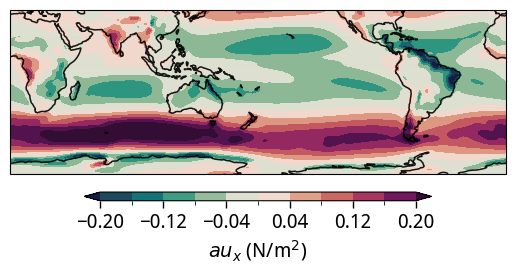

In [90]:
xx, yy = np.meshgrid(surface_da_pi.lon, surface_da_pi.lat)

plot_single_map(xx, yy, surface_da_pi, '', '', cmap=cmocean.cm.curl, levels = np.linspace(-0.2, 0.2, 11), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(8,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
                cbar_kwargs=dict(orientation='horizontal', label='$\tau_x$ (N/m$^{2}$)', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False)

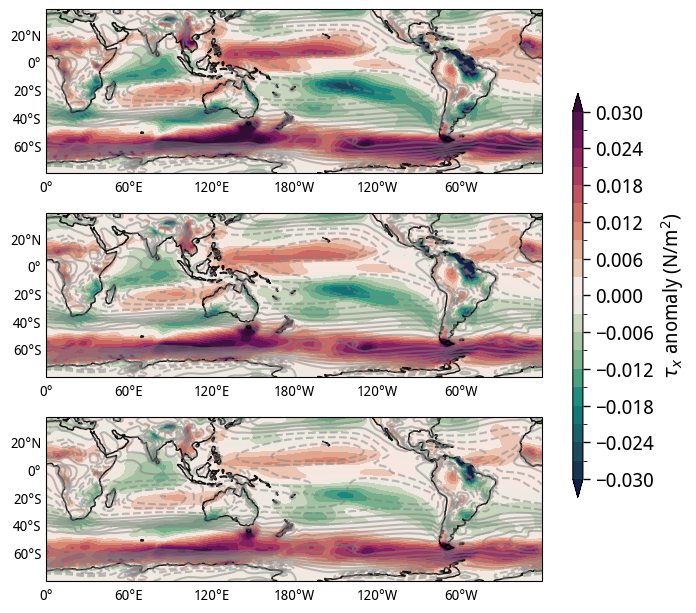

In [91]:
xx, yy = np.meshgrid(surface_da_list[0].lon, surface_da_list[0].lat)
plot_maps(xx, yy, surface_da_list, titles=['']*8, labels=['']*9, cmap=cmocean.cm.curl, levels=np.linspace(-0.03, 0.03, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=[surface_da_pi]*9, contour_levels=np.linspace(-0.15, 0.15, 11), contour_colors='gray', 
            nrows=3, ncols=1, figsize=(8,7.5), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label=r'$\tau_x$ anomaly (N/m$^{2}$)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=False)

In [96]:
zonal_da_list = [
    compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), time = slice('2045', '2075')).mean(('time', 'model'))/1e9, type='zonal'),
    compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), time = slice('2030', '2060')).mean(('time', 'model'))/1e9, type='zonal'),
    compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), time = slice('2015', '2045')).mean(('time', 'model'))/1e9, type='zonal'),
]

In [97]:

zonal_da_pi = compute_plotting_da(msftmz_trans_orig.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), time = slice('1850', '1900')).mean(('time', 'model'))/1e9, type='zonal')

Text(0, 0.5, 'Depth (m)')

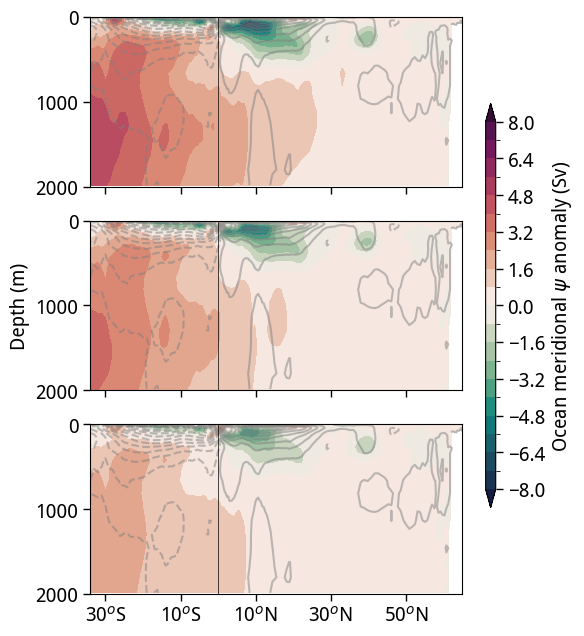

In [98]:
xx, yy = np.meshgrid(zonal_da_list[0].lat, zonal_da_list[0].lev)
fig, axlist = plot_maps_no_proj(xx, yy, zonal_da_list, titles=['']*8, labels=['']*9, cmap=cmocean.cm.curl, levels=np.linspace(-8, 8, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=[zonal_da_pi]*9, contour_levels=np.linspace(-40, 40, 21), contour_colors='gray', 
                nrows=3, ncols=1, figsize=(6,7.5), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig',
                cbar_kwargs=dict(orientation='vertical', label=r'Ocean meridional $\psi$ anomaly (Sv)', aspect=40, shrink=0.7, pad=0.05), draw_colorbar=True, auto_aspect=False)

for ax in axlist:
    ax.invert_yaxis()
    ax.axvline(0.0, color='k', lw=0.5)
axlist[2].set_xticks([-30, -10, 10, 30, 50], labels=['30$^{o}$S','10$^{o}$S', '10$^{o}$N', '30$^{o}$N', '50$^{o}$N'])
for ax in axlist:
    ax.set_yticks([0, 1000, 2000])
    # ax.set_yticks([0, 100, 200])
# axlist[2].set_xlabel('Latitude')
axlist[1].set_ylabel('Depth (m)')

In [113]:
zonal_da_list = [
    compute_plotting_da(msftmz_trans.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), time = slice('2045', '2075')).mean(('time', 'model'))/1e9, type='zonal'),
    compute_plotting_da(msftmz_trans.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), time = slice('2030', '2060')).mean(('time', 'model'))/1e9, type='zonal'),
    compute_plotting_da(msftmz_trans.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), time = slice('2015', '2045')).mean(('time', 'model'))/1e9, type='zonal'),
]


In [114]:
zonal_da_pi = compute_plotting_da(msftmz_trans_orig.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), time = slice('1850', '1900')).mean(('time', 'model'))/1e9, type='zonal')

Text(0, 0.5, 'Depth (m)')

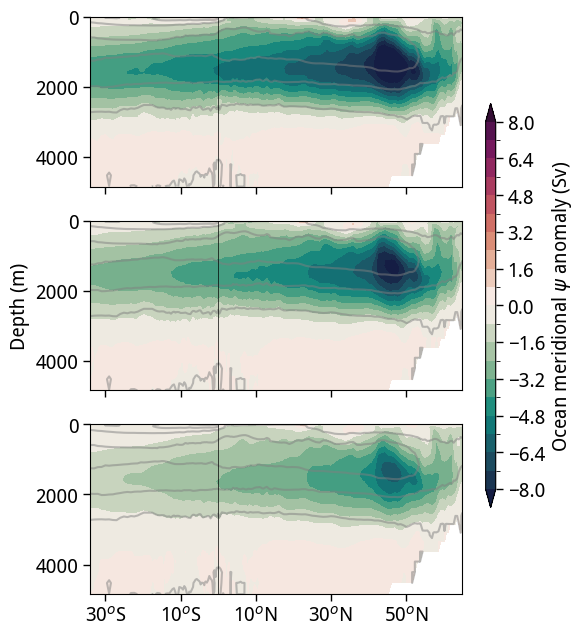

In [115]:
xx, yy = np.meshgrid(zonal_da_list[0].lat, zonal_da_list[0].lev)
fig, axlist = plot_maps_no_proj(xx, yy, zonal_da_list, titles=['']*8, labels=['']*9, cmap=cmocean.cm.curl, levels=np.linspace(-8, 8, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=[zonal_da_pi]*9, contour_levels=np.linspace(-80, 80, 21), contour_colors='gray', 
                nrows=3, ncols=1, figsize=(6,7.5), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig',
                cbar_kwargs=dict(orientation='vertical', label=r'Ocean meridional $\psi$ anomaly (Sv)', aspect=40, shrink=0.7, pad=0.05), draw_colorbar=True, auto_aspect=False)

for ax in axlist:
    ax.invert_yaxis()
    ax.axvline(0.0, color='k', lw=0.5)
axlist[2].set_xticks([-30, -10, 10, 30, 50], labels=['30$^{o}$S','10$^{o}$S', '10$^{o}$N', '30$^{o}$N', '50$^{o}$N'])
# axlist[2].set_xlabel('Latitude')
for ax in axlist:
    ax.set_yticks([0, 2000, 4000])
axlist[1].set_ylabel('Depth (m)')

In [120]:
zonal_da_list = [
    compute_plotting_da(msftmz_trans.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), time = slice('2045', '2075')).mean(('time', 'model'))/1e9, type='zonal'),
    compute_plotting_da(msftmz_trans.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), time = slice('2030', '2060')).mean(('time', 'model'))/1e9, type='zonal'),
    compute_plotting_da(msftmz_trans.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), time = slice('2015', '2045')).mean(('time', 'model'))/1e9, type='zonal'),
]


In [121]:
zonal_da_pi = compute_plotting_da(msftmz_trans_orig.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), time = slice('1850', '1900')).mean(('time', 'model'))/1e9, type='zonal')

Text(0, 0.5, 'Depth (m)')

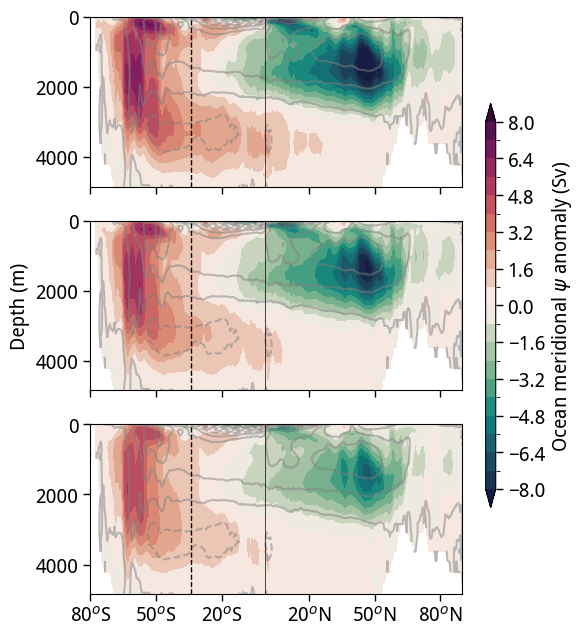

In [122]:
xx, yy = np.meshgrid(zonal_da_list[0].lat, zonal_da_list[0].lev)
fig, axlist = plot_maps_no_proj(xx, yy, zonal_da_list, titles=['']*8, labels=['']*9, cmap=cmocean.cm.curl, levels=np.linspace(-8, 8, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=[zonal_da_pi]*9, contour_levels=np.linspace(-80, 80, 21), contour_colors='gray', 
                nrows=3, ncols=1, figsize=(6,7.5), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig',
                cbar_kwargs=dict(orientation='vertical', label=r'Ocean meridional $\psi$ anomaly (Sv)', aspect=40, shrink=0.7, pad=0.05), draw_colorbar=True, auto_aspect=False)

for ax in axlist:
    ax.invert_yaxis()
    ax.axvline(0.0, color='k', lw=0.5)
    ax.set_yticks([0, 2000, 4000])
    ax.axvline(-34, color='k', ls='--', lw=1.0)
axlist[2].set_xticks([-80, -50, -20, 20, 50, 80], labels=['80$^{o}$S','50$^{o}$S', '20$^{o}$S', '20$^{o}$N', '50$^{o}$N', '80$^{o}$N'])

# axlist[2].set_xlabel('Latitude')
axlist[1].set_ylabel('Depth (m)')

In [84]:

merid_da_list = [
    compute_plotting_da(thetao_tropics_trans.sel(time = slice('2045', '2075')).mean(('time', 'model')), type='merid').sel(lon = slice(120, 270)),
    compute_plotting_da(thetao_tropics_trans.sel(time = slice('2030', '2060')).mean(('time', 'model')), type='merid').sel(lon = slice(120, 270)),
    compute_plotting_da(thetao_tropics_trans.sel(time = slice('2015', '2045')).mean(('time', 'model')), type='merid').sel(lon = slice(120, 270)),
]

In [120]:
merid_da_pi = compute_plotting_da(thetao_tropics_trans_orig.sel(time = slice('1850', '1900')).mean(('time', 'model')), type='merid').sel(lon = slice(120, 270))

Text(0, 0.5, 'Depth (m)')

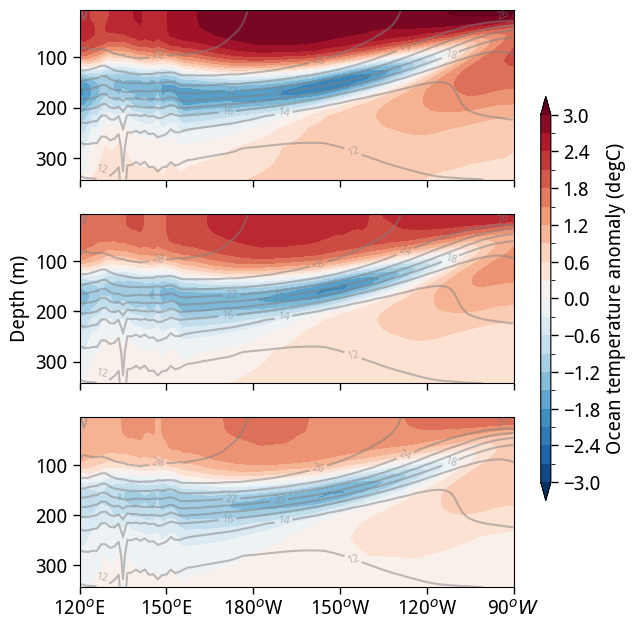

In [121]:
xx, yy = np.meshgrid(merid_da_list[0].lon, merid_da_list[0].lev)
fig, axlist = plot_maps_no_proj(xx, yy, merid_da_list, titles=['']*8, labels=['']*9, cmap='RdBu_r', levels=np.linspace(-3, 3, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=[merid_da_pi]*9, contour_levels=np.linspace(10, 30, 11), contour_colors='gray', 
                nrows=3, ncols=1, figsize=(7,7.5), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig',
                cbar_kwargs=dict(orientation='vertical', label=r'Ocean temperature anomaly (degC)', aspect=40, shrink=0.7, pad=0.05), draw_colorbar=True, auto_aspect=False, draw_clabel=True)

for ax in axlist:
    ax.invert_yaxis()
    # ax.axvline(0.0, color='k', lw=0.5)
axlist[2].set_xticks([120, 150, 180, 210,  240, 270], labels = ['120$^{o}$E', '150$^{o}$E', '180$^{o}$W', '150$^{o}$W',  '120$^{o}$W', '90$^{o}W$'])
# axlist[2].set_xlabel('Longitude')
axlist[1].set_ylabel('Depth (m)')

In [85]:

def additional_sampling_stabilisation(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer)).mean('time')
        da_list.append(sample_da)
        i += spacer
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))
    print('Done')


def additional_sampling_stabilisation_nomeans(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer))
        da_list.append(sample_da)
        i += spacer
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))
    print('Done')

In [92]:
surface_da_list_stable = [
    additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2060', lat = slice(-80, 40))).mean(('model')),
    additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2045', lat = slice(-80, 40))).mean(('model')),
    additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2030', lat = slice(-80, 40))).mean(('model')),
]
print('Done')


Done


In [93]:
surface_da_list_diff = [
    surface_da_list_stable[0] - surface_da_list[0],
    surface_da_list_stable[1] - surface_da_list[1],
    surface_da_list_stable[2] - surface_da_list[2],
]


In [94]:
surface_pval_list = [
    funcs.mannwhitneyu3d(additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2060', lat = slice(-80, 40), time = slice('2060', '3060')).ffill('time')), tauu_trans.tauu.sel(time = slice('2045', '2075'), lat = slice(-80, 40)).mean(('time')), dim='model'),
    funcs.mannwhitneyu3d(additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2045', lat = slice(-80, 40), time = slice('2045', '3045')).ffill('time')), tauu_trans.tauu.sel(time = slice('2030', '2060'), lat = slice(-80, 40)).mean(('time')), dim='model'),
    funcs.mannwhitneyu3d(additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2030', lat = slice(-80, 40), time = slice('2030', '3030')).ffill('time')), tauu_trans.tauu.sel(time = slice('2015', '2045'), lat = slice(-80, 40)).mean(('time')), dim='model'),
    
]
print('Done')


Done


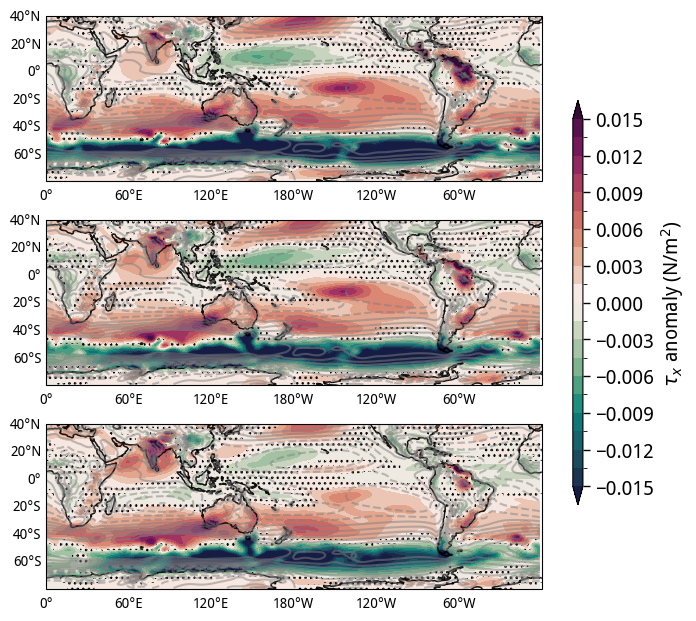

In [95]:
xx, yy = np.meshgrid(surface_da_list_diff[0].lon, surface_da_list_diff[0].lat)
plot_maps(xx, yy, surface_da_list_diff, titles=['']*8, labels=['']*9, cmap=cmocean.cm.curl, levels=np.linspace(-0.015, 0.015, 21), pval = surface_pval_list, draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=[surface_da_pi]*9, contour_levels=np.linspace(-0.15, 0.15, 11), contour_colors='gray', 
            nrows=3, ncols=1, figsize=(8,7.5), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label=r'$\tau_x$ anomaly (N/m$^{2}$)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=False)

In [99]:
zonal_da_list_stable = [
    compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), model = '2060')).mean(('model'))/1e9, type='zonal'),
    compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), model = '2045')).mean(('model'))/1e9, type='zonal'),
    compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), model = '2030')).mean(('model'))/1e9, type='zonal'),
]
print('Done')

Done


In [100]:
zonal_da_list_diff = [
    zonal_da_list_stable[0] - zonal_da_list[0],
    zonal_da_list_stable[1] - zonal_da_list[1],
    zonal_da_list_stable[2] - zonal_da_list[2],
]

In [101]:
zonal_pval_list = [
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), model = '2060').sel(time = slice('2060', '3060')).ffill('time'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), time = slice('2045', '2075')).mean(('time'))/1e9, type='zonal'), dim='model'),
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), model = '2045').sel(time = slice('2045', '3045')).ffill('time'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), time = slice('2030', '2060')).mean(('time'))/1e9, type='zonal'), dim='model'),
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), model = '2030').sel(time = slice('2030', '3030')).ffill('time'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 2000), lat = slice(-34, 65), time = slice('2015', '2045')).mean(('time'))/1e9, type='zonal'), dim='model'),
]
print('Done')

Done


Text(0, 0.5, 'Depth (m)')

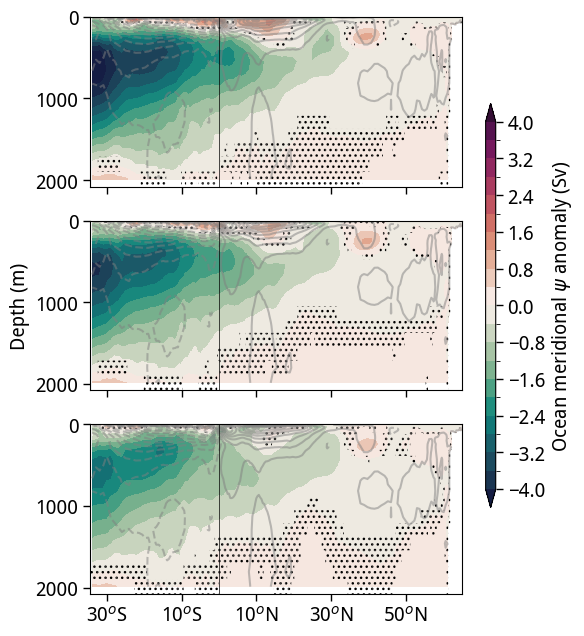

In [102]:
xx, yy = np.meshgrid(zonal_da_list_diff[0].lat, zonal_da_list_diff[0].lev)
fig, axlist = plot_maps_no_proj(xx, yy, zonal_da_list_diff, titles=['']*8, labels=['']*9, cmap=cmocean.cm.curl, levels=np.linspace(-4, 4, 21), pval = zonal_pval_list, draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=[zonal_da_pi]*9, contour_levels=np.linspace(-40, 40, 21), contour_colors='gray', 
                nrows=3, ncols=1, figsize=(6,7.5), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig',
                cbar_kwargs=dict(orientation='vertical', label=r'Ocean meridional $\psi$ anomaly (Sv)', aspect=40, shrink=0.7, pad=0.05), draw_colorbar=True, auto_aspect=False)

for ax in axlist:
    ax.invert_yaxis()
    ax.axvline(0.0, color='k', lw=0.5)
axlist[2].set_xticks([-30, -10, 10, 30, 50], labels=['30$^{o}$S','10$^{o}$S', '10$^{o}$N', '30$^{o}$N', '50$^{o}$N' ])
for ax in axlist:
    ax.set_yticks([0, 1000, 2000])
# axlist[2].set_xlabel('Latitude')
axlist[1].set_ylabel('Depth (m)')

In [116]:
zonal_da_list_stable = [
    compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), model = '2060')).mean(('model'))/1e9, type='zonal'),
    compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), model = '2045')).mean(('model'))/1e9, type='zonal'),
    compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), model = '2030')).mean(('model'))/1e9, type='zonal'),
]
print('Done')

Done


In [117]:
zonal_da_list_diff = [
    zonal_da_list_stable[0] - zonal_da_list[0],
    zonal_da_list_stable[1] - zonal_da_list[1],
    zonal_da_list_stable[2] - zonal_da_list[2],
]

In [118]:
zonal_pval_list = [
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), model = '2060').sel(time = slice('2060', '3060')).ffill('time'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), time = slice('2045', '2075')).mean(('time'))/1e9, type='zonal'), dim='model'),
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), model = '2045').sel(time = slice('2045', '3045')).ffill('time'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), time = slice('2030', '2060')).mean(('time'))/1e9, type='zonal'), dim='model'),
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), model = '2030').sel(time = slice('2030', '3030')).ffill('time'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=0).sel(lev = slice(0, 5000), lat = slice(-34, 65), time = slice('2015', '2045')).mean(('time'))/1e9, type='zonal'), dim='model'),
]
print('Done')

Done


Text(0, 0.5, 'Depth (m)')

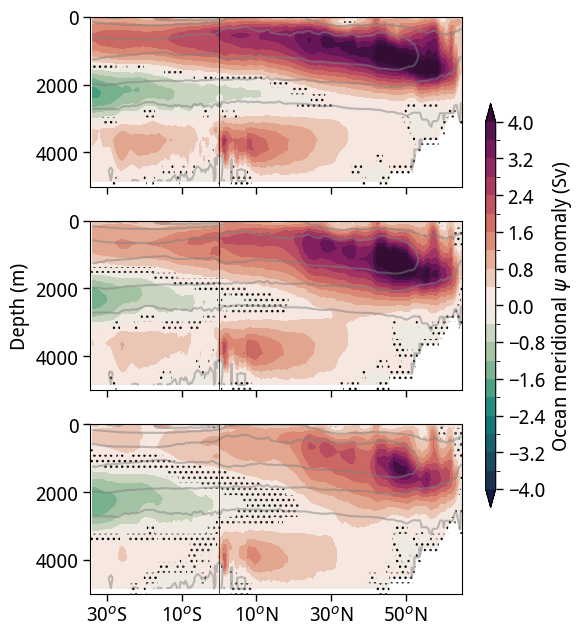

In [119]:
xx, yy = np.meshgrid(zonal_da_list_diff[0].lat, zonal_da_list_diff[0].lev)
fig, axlist = plot_maps_no_proj(xx, yy, zonal_da_list_diff, titles=['']*8, labels=['']*9, cmap=cmocean.cm.curl, levels=np.linspace(-4, 4, 21), pval = zonal_pval_list, draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=[zonal_da_pi]*9, contour_levels=np.linspace(-80, 80, 21), contour_colors='gray', 
                nrows=3, ncols=1, figsize=(6,7.5), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig',
                cbar_kwargs=dict(orientation='vertical', label=r'Ocean meridional $\psi$ anomaly (Sv)', aspect=40, shrink=0.7, pad=0.05), draw_colorbar=True, auto_aspect=False)

for ax in axlist:
    ax.invert_yaxis()
    ax.axvline(0.0, color='k', lw=0.5)
axlist[2].set_xticks([-30, -10, 10, 30, 50], labels=['30$^{o}$S','10$^{o}$S', '10$^{o}$N', '30$^{o}$N', '50$^{o}$N'])
# axlist[2].set_xlabel('Latitude')
for ax in axlist:
    ax.set_yticks([0, 2000, 4000])
# axlist[2].set_xlabel('Latitude')
axlist[1].set_ylabel('Depth (m)')

In [123]:
zonal_da_list_stable = [
    compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), model = '2060')).mean(('model'))/1e9, type='zonal'),
    compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), model = '2045')).mean(('model'))/1e9, type='zonal'),
    compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), model = '2030')).mean(('model'))/1e9, type='zonal'),
]
print('Done')

Done


In [124]:
zonal_da_list_diff = [
    zonal_da_list_stable[0] - zonal_da_list[0],
    zonal_da_list_stable[1] - zonal_da_list[1],
    zonal_da_list_stable[2] - zonal_da_list[2],
]

In [125]:
zonal_pval_list = [
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), model = '2060').sel(time = slice('2060', '3060')).ffill('time'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), time = slice('2045', '2075')).mean(('time'))/1e9, type='zonal'), dim='model'),
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), model = '2045').sel(time = slice('2045', '3045')).ffill('time'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), time = slice('2030', '2060')).mean(('time'))/1e9, type='zonal'), dim='model'),
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), model = '2030').sel(time = slice('2030', '3030')).ffill('time'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=2).sel(lev = slice(0, 5000), lat = slice(-80, 90), time = slice('2015', '2045')).mean(('time'))/1e9, type='zonal'), dim='model'),
]
print('Done')

Done


Text(0, 0.5, 'Depth (m)')

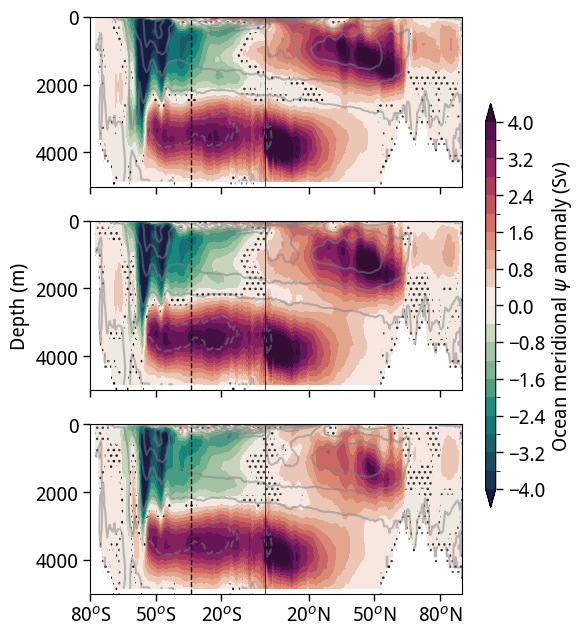

In [126]:
xx, yy = np.meshgrid(zonal_da_list_diff[0].lat, zonal_da_list_diff[0].lev)
fig, axlist = plot_maps_no_proj(xx, yy, zonal_da_list_diff, titles=['']*8, labels=['']*9, cmap=cmocean.cm.curl, levels=np.linspace(-4, 4, 21), pval = zonal_pval_list, draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=[zonal_da_pi]*9, contour_levels=np.linspace(-80, 80, 21), contour_colors='gray', 
                nrows=3, ncols=1, figsize=(6,7.5), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig',
                cbar_kwargs=dict(orientation='vertical', label=r'Ocean meridional $\psi$ anomaly (Sv)', aspect=40, shrink=0.7, pad=0.05), draw_colorbar=True, auto_aspect=False)

for ax in axlist:
    ax.invert_yaxis()
    ax.axvline(0.0, color='k', lw=0.5)
    ax.set_yticks([0, 2000, 4000])
    ax.axvline(-34, color='k', ls='--', lw=1.0)
axlist[2].set_xticks([-80, -50, -20, 20, 50, 80], labels=['80$^{o}$S','50$^{o}$S', '20$^{o}$S', '20$^{o}$N', '50$^{o}$N', '80$^{o}$N'])
# axlist[2].set_xlabel('Latitude')
axlist[1].set_ylabel('Depth (m)')

In [127]:
merid_da_list_stable = [
    compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2060.thetao).mean(('model')), type='merid', alternate=True).sel(lon = slice(120, 270)),
    compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2045.thetao).mean(('model')), type='merid', alternate=True).sel(lon = slice(120, 270)),
    compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2030.thetao).mean(('model')), type='merid', alternate=True).sel(lon = slice(120, 270)),
]
print('Done')

Done


In [128]:
merid_pval_list = [
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2060.thetao.ffill('time')), type='merid', alternate=True).sel(lon = slice(120, 270)), compute_plotting_da(thetao_tropics_trans.sel(time = slice('2045', '2075')).mean(('time')).load(), type='merid').sel(lon = slice(120, 270)), dim='model'),
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2045.thetao.ffill('time')), type='merid', alternate=True).sel(lon = slice(120, 270)), compute_plotting_da(thetao_tropics_trans.sel(time = slice('2030', '2060')).mean(('time')).load(), type='merid').sel(lon = slice(120, 270)), dim='model'),
    funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2030.thetao.ffill('time')), type='merid', alternate=True).sel(lon = slice(120, 270)), compute_plotting_da(thetao_tropics_trans.sel(time = slice('2015', '2045')).mean(('time')).load(), type='merid').sel(lon = slice(120, 270)), dim='model'),
]
print('Done')

Done


In [ ]:
merid_da_list_diff = [
    merid_da_list_stable[0] - merid_da_list[0],
    merid_da_list_stable[1] - merid_da_list[1],
    merid_da_list_stable[2] - merid_da_list[2],
]

Text(0, 0.5, 'Depth (m)')

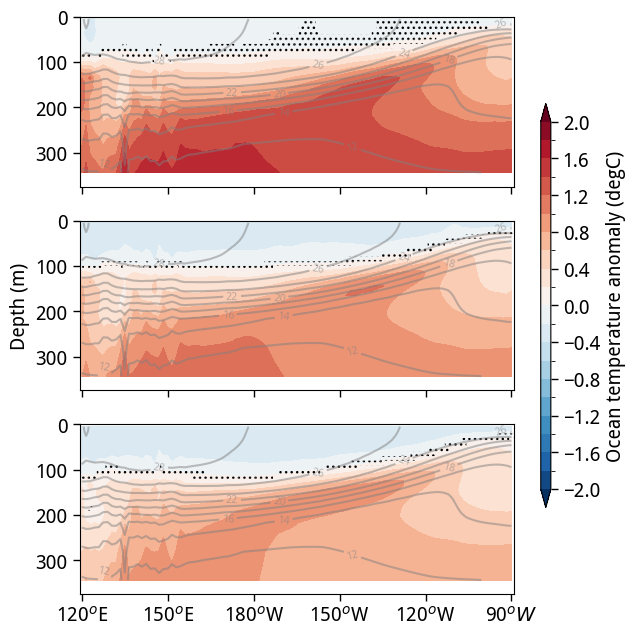

In [141]:
xx, yy = np.meshgrid(merid_da_list_diff[0].lon, merid_da_list_diff[0].lev)
fig, axlist = plot_maps_no_proj(xx, yy, merid_da_list_diff, titles=['']*8, labels=['']*9, cmap='RdBu_r', levels=np.linspace(-2, 2, 21), pval = merid_pval_list, draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=[merid_da_pi]*9, contour_levels=np.linspace(10, 30, 11), contour_colors='gray', 
                nrows=3, ncols=1, figsize=(7,7.5), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig',
                cbar_kwargs=dict(orientation='vertical', label=r'Ocean temperature anomaly (degC)', aspect=40, shrink=0.7, pad=0.05), draw_colorbar=True, auto_aspect=False, draw_clabel=True)

for ax in axlist:
    ax.invert_yaxis()
    # ax.axvline(0.0, color='k', lw=0.5)
axlist[2].set_xticks([120, 150, 180, 210,  240, 270], labels = ['120$^{o}$E', '150$^{o}$E', '180$^{o}$W', '150$^{o}$W',  '120$^{o}$W', '90$^{o}W$'])
# axlist[2].set_xlabel('Longitude')
axlist[1].set_ylabel('Depth (m)')

### old 3d code

In [ ]:
# surface_da = tauu_trans_orig.tauu.sel(time = slice('1850', '1900'), lat = slice(-30, 30)).mean(('time', 'model'))
# zonal_da = compute_plotting_da(msftmz_trans_orig.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), time = slice('1850', '1900')).mean(('time', 'model'))/1e9, type='zonal')
# merid_da = compute_plotting_da(thet'ao_tropics_trans_orig.sel(time = slice('1850', '1900')).mean(('time', 'model')), type='merid')

# ax = plot_single_cuboid_contours(surface_da, zonal_da, merid_da, 
#                                 levels = dict(surface = np.linspace(-0.15, 0.15, 21), 
#                                               zonal = np.linspace(-40, 40, 21), 
#                                               merid = np.linspace(10, 30, 21)), 
#                                 cmap = dict(surface = 'PuOr_r', 
#                                               zonal = cmocean.cm.curl, 
#                                               merid = 'RdBu_r'),
#                                 figsize=(10,10), basemap_type='land')

# ax.view_init(40, -45, 0)
# # ax.set_box_aspect(None, zoom=1.0)
# ax.set_box_aspect((2.0,1.0,0.8))
# # return ax

In [ ]:
# surface_da_list = [
#     tauu_trans.tauu.sel(time = slice('2045', '2075'), lat = slice(-30, 30)).mean(('time', 'model')),
#     tauu_trans.tauu.sel(time = slice('2030', '2060'), lat = slice(-30, 30)).mean(('time', 'model')),
#     tauu_trans.tauu.sel(time = slice('2015', '2045'), lat = slice(-30, 30)).mean(('time', 'model')),
# ]

# zonal_da_list = [
#     compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), time = slice('2045', '2075')).mean(('time', 'model'))/1e9, type='zonal'),
#     compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), time = slice('2030', '2060')).mean(('time', 'model'))/1e9, type='zonal'),
#     compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), time = slice('2015', '2045')).mean(('time', 'model'))/1e9, type='zonal'),
# ]

# merid_da_list = [
#     compute_plotting_da(thetao_tropics_trans.sel(time = slice('2045', '2075')).mean(('time', 'model')), type='merid'),
#     compute_plotting_da(thetao_tropics_trans.sel(time = slice('2030', '2060')).mean(('time', 'model')), type='merid'),
#     compute_plotting_da(thetao_tropics_trans.sel(time = slice('2015', '2045')).mean(('time', 'model')), type='merid'),
# ]

In [37]:
# plot_cuboid_contours(
#     surface_da_list, zonal_da_list, merid_da_list,
#     levels = dict(surface = np.linspace(-0.03, 0.03, 21), 
#                   zonal = np.linspace(-8, 8, 21), 
#                   merid = np.linspace(-3, 3, 21)), 
#     cmap = dict(surface = 'PuOr_r', 
#                   zonal = cmocean.cm.curl, 
#                   merid = 'RdBu_r'),
#     figsize=(12, 12), basemap_type='land',
#     nrows=3, ncols=1,
#     box_aspect=(2, 1, 0.8),  # (x, y, z) scaling
#     hspace=0.05, wspace=0.05,  # control gaps
# )

In [ ]:
# surface_da_list_stable = [
#     additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2060', lat = slice(-30, 30))).mean(('model')),
#     additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2045', lat = slice(-30, 30))).mean(('model')),
#     additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2030', lat = slice(-30, 30))).mean(('model')),
# ]
# print('Done')

# zonal_da_list_stable = [
#     compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), model = '2060')).mean(('model'))/1e9, type='zonal'),
#     compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), model = '2045')).mean(('model'))/1e9, type='zonal'),
#     compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), model = '2030')).mean(('model'))/1e9, type='zonal'),
# ]
# print('Done')

# merid_da_list_stable = [
#     compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2060.thetao).mean(('model')), type='merid', alternate=True),
#     compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2045.thetao).mean(('model')), type='merid', alternate=True),
#     compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2030.thetao).mean(('model')), type='merid', alternate=True),
# ]
# print('Done')

Done
Done
Done


In [36]:
# plot_cuboid_contours(
#     surface_da_list_stable, zonal_da_list_stable, merid_da_list_stable,
#     levels = dict(surface = np.linspace(-0.03, 0.03, 21), 
#                   zonal = np.linspace(-8, 8, 21), 
#                   merid = np.linspace(-3, 3, 21)), 
#     cmap = dict(surface = 'PuOr', 
#                   zonal = cmocean.cm.curl, 
#                   merid = 'RdBu_r'),
#     figsize=(12, 12), basemap_type='land',
#     nrows=3, ncols=1,
#     box_aspect=(2, 1, 0.8),  # (x, y, z) scaling
#     hspace=0.05, wspace=0.05,  # control gaps
# )

In [33]:
# surface_da_list_diff = [
#     surface_da_list_stable[0] - surface_da_list[0],
#     surface_da_list_stable[1] - surface_da_list[1],
#     surface_da_list_stable[2] - surface_da_list[2],
# ]

# zonal_da_list_diff = [
#     zonal_da_list_stable[0] - zonal_da_list[0],
#     zonal_da_list_stable[1] - zonal_da_list[1],
#     zonal_da_list_stable[2] - zonal_da_list[2],
# ]

# merid_da_list_diff = [
#     merid_da_list_stable[0] - merid_da_list[0],
#     merid_da_list_stable[1] - merid_da_list[1],
#     merid_da_list_stable[2] - merid_da_list[2],
# ]

In [34]:
# surface_pval_list = [
#     funcs.mannwhitneyu3d(additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2060', lat = slice(-30, 30))), tauu_trans.tauu.sel(time = slice('2045', '2075'), lat = slice(-30, 30)).mean(('time')), dim='model'),
#     funcs.mannwhitneyu3d(additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2045', lat = slice(-30, 30))), tauu_trans.tauu.sel(time = slice('2030', '2060'), lat = slice(-30, 30)).mean(('time')), dim='model'),
#     funcs.mannwhitneyu3d(additional_sampling_stabilisation(tauu_stable.tauu.sel(model = '2030', lat = slice(-30, 30))), tauu_trans.tauu.sel(time = slice('2015', '2045'), lat = slice(-30, 30)).mean(('time')), dim='model'),
    
# ]
# print('Done')

# zonal_pval_list = [
#     funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), model = '2060'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), time = slice('2045', '2075')).mean(('time'))/1e9, type='zonal'), dim='model'),
#     funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), model = '2045'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), time = slice('2030', '2060')).mean(('time'))/1e9, type='zonal'), dim='model'),
#     funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(msftmz_stable.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), model = '2030'))/1e9, type='zonal'),  compute_plotting_da(msftmz_trans.msftmz.isel(basin=1).sel(lev = slice(0, 350), lat = slice(-30, 30), time = slice('2015', '2045')).mean(('time'))/1e9, type='zonal'), dim='model'),
# ]
# print('Done')

# merid_pval_list = [
#     funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2060.thetao), type='merid', alternate=True), compute_plotting_da(thetao_tropics_trans.sel(time = slice('2045', '2075')).mean(('time')).load(), type='merid'), dim='model'),
#     funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2045.thetao), type='merid', alternate=True), compute_plotting_da(thetao_tropics_trans.sel(time = slice('2030', '2060')).mean(('time')).load(), type='merid'), dim='model'),
#     funcs.mannwhitneyu3d(compute_plotting_da(additional_sampling_stabilisation(thetao_tropics_stable_anom2030.thetao), type='merid', alternate=True), compute_plotting_da(thetao_tropics_trans.sel(time = slice('2015', '2045')).mean(('time')).load(), type='merid'), dim='model'),
# ]
# print('Done')

In [35]:
# plot_cuboid_contours(
#     surface_da_list_diff, zonal_da_list_diff, merid_da_list_diff,
#     surface_pval_list, zonal_pval_list, merid_pval_list,
#     levels = dict(surface = np.linspace(-0.015, 0.015, 21), 
#                   zonal = np.linspace(-4, 4, 21), 
#                   merid = np.linspace(-2, 2, 21)), 
#     cmap = dict(surface = 'PuOr_r', 
#                   zonal = cmocean.cm.curl, 
#                   merid = 'RdBu_r'),
#     figsize=(12, 12), basemap_type='land',
#     nrows=3, ncols=1,
#     box_aspect=(2, 1, 0.8),  # (x, y, z) scaling
#     hspace=0.05, wspace=0.05,  # control gaps
# )